## 05 — Contrastive Training: H&E Image Embeddings ↔ Gene Expression

This notebook trains the first HistoGeneAlign contrastive baseline.

Input:

    data/embeddings/TENX95_resnet50_image_embeddings_qc.npy
    data/embeddings/TENX95_resnet50_image_embedding_metadata_qc.csv
    data/raw/hest/st/TENX95.h5ad

Model:

    Frozen ResNet-50 image embeddings
        → trainable image projection head
        → shared latent space

    QC gene-expression vector
        → log-normalization
        → trainable gene encoder
        → trainable gene projection head
        → shared latent space

Objective:

    Symmetric CLIP-style InfoNCE loss

Evaluation during training:

    Image → Gene Recall@1 / Recall@5 / Recall@10 / Median Rank / MRR
    Gene → Image Recall@1 / Recall@5 / Recall@10 / Median Rank / MRR

In [16]:
# ============================================================
# Imports, reproducibility, paths, and device setup
# ============================================================

from pathlib import Path
import json
import random
import gc
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import sparse

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from tqdm.auto import tqdm


# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True


# ------------------------------------------------------------
# Project root detection
# ------------------------------------------------------------

def find_project_root(start_path=None):
    start_path = Path.cwd() if start_path is None else Path(start_path).resolve()

    for candidate in [start_path] + list(start_path.parents):
        if (candidate / "config.yaml").exists() and (candidate / "data").exists():
            return candidate
        if (candidate / "notebooks").exists() and (candidate / "data").exists():
            return candidate

    if start_path.name == "notebooks":
        return start_path.parent

    return start_path


PROJECT_ROOT = find_project_root()

SAMPLE_ID = "TENX95"

RAW_DIR = PROJECT_ROOT / "data" / "raw" / "hest"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
EMBEDDINGS_DIR = PROJECT_ROOT / "data" / "embeddings"
SPLITS_DIR = PROJECT_ROOT / "data" / "splits"

FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
METRICS_DIR = PROJECT_ROOT / "outputs" / "metrics"
CHECKPOINT_DIR = PROJECT_ROOT / "outputs" / "checkpoints"

for d in [PROCESSED_DIR, EMBEDDINGS_DIR, SPLITS_DIR, FIGURE_DIR, METRICS_DIR, CHECKPOINT_DIR]:
    d.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# Input paths from Notebook 04
# ------------------------------------------------------------

QC_IMAGE_EMBEDDING_PATH = EMBEDDINGS_DIR / f"{SAMPLE_ID}_resnet50_image_embeddings_qc.npy"
QC_METADATA_PATH = EMBEDDINGS_DIR / f"{SAMPLE_ID}_resnet50_image_embedding_metadata_qc.csv"
ADATA_PATH = RAW_DIR / "st" / f"{SAMPLE_ID}.h5ad"


# ------------------------------------------------------------
# Output paths for Notebook 05
# ------------------------------------------------------------

GENE_FEATURE_PATH = PROCESSED_DIR / f"{SAMPLE_ID}_gene_features_qc_lognorm_scaled.npy"
SPLIT_PATH = SPLITS_DIR / f"{SAMPLE_ID}_random_split_indices.npz"

CHECKPOINT_PATH = CHECKPOINT_DIR / f"{SAMPLE_ID}_resnet50_contrastive_baseline.pt"
TRAINING_HISTORY_PATH = METRICS_DIR / f"{SAMPLE_ID}_contrastive_training_history.csv"
FINAL_TEST_METRICS_PATH = METRICS_DIR / f"{SAMPLE_ID}_contrastive_final_test_metrics.json"

LATENT_IMAGE_PATH = EMBEDDINGS_DIR / f"{SAMPLE_ID}_resnet50_contrastive_image_latents_qc.npy"
LATENT_GENE_PATH = EMBEDDINGS_DIR / f"{SAMPLE_ID}_resnet50_contrastive_gene_latents_qc.npy"
LATENT_METADATA_PATH = EMBEDDINGS_DIR / f"{SAMPLE_ID}_contrastive_qc_metadata_with_splits.csv"


# ------------------------------------------------------------
# Device
# ------------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Project root:", PROJECT_ROOT)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA runtime:", torch.version.cuda)

print("\nInput files:")
print(QC_IMAGE_EMBEDDING_PATH, "| exists:", QC_IMAGE_EMBEDDING_PATH.exists())
print(QC_METADATA_PATH, "| exists:", QC_METADATA_PATH.exists())
print(ADATA_PATH, "| exists:", ADATA_PATH.exists())

Project root: c:\Users\Hareen\Desktop\HistoGeneAlign
Device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
CUDA runtime: 12.8

Input files:
c:\Users\Hareen\Desktop\HistoGeneAlign\data\embeddings\TENX95_resnet50_image_embeddings_qc.npy | exists: True
c:\Users\Hareen\Desktop\HistoGeneAlign\data\embeddings\TENX95_resnet50_image_embedding_metadata_qc.csv | exists: True
c:\Users\Hareen\Desktop\HistoGeneAlign\data\raw\hest\st\TENX95.h5ad | exists: True


In [17]:
# ============================================================
# Loading QC image embeddings, QC metadata, and AnnData
# ============================================================

assert QC_IMAGE_EMBEDDING_PATH.exists(), f"Missing file: {QC_IMAGE_EMBEDDING_PATH}"
assert QC_METADATA_PATH.exists(), f"Missing file: {QC_METADATA_PATH}"
assert ADATA_PATH.exists(), f"Missing file: {ADATA_PATH}"

qc_image_embeddings = np.load(QC_IMAGE_EMBEDDING_PATH).astype(np.float32)
qc_metadata = pd.read_csv(QC_METADATA_PATH)

try:
    import scanpy as sc
    adata = sc.read_h5ad(ADATA_PATH)
    print("Loaded AnnData with scanpy.")
except ImportError:
    import anndata as ad
    adata = ad.read_h5ad(ADATA_PATH)
    print("Loaded AnnData with anndata.")

print("\nQC image embeddings shape:", qc_image_embeddings.shape)
print("QC metadata shape:", qc_metadata.shape)
print("AnnData shape:", adata.shape)

required_cols = [
    "embedding_row",
    "embedding_row_full",
    "spot_id",
    "patch_index",
    "ann_data_row",
    "library_size",
    "detected_genes",
]

for col in required_cols:
    assert col in qc_metadata.columns, f"Missing required column: {col}"

assert qc_image_embeddings.ndim == 2
assert qc_image_embeddings.shape[0] == len(qc_metadata)
assert qc_image_embeddings.shape[1] == 2048
assert np.isfinite(qc_image_embeddings).all()

assert qc_metadata["embedding_row"].is_unique
assert qc_metadata["spot_id"].is_unique
assert qc_metadata["patch_index"].is_unique
assert qc_metadata["ann_data_row"].is_unique

assert np.array_equal(
    qc_metadata["embedding_row"].to_numpy(),
    np.arange(len(qc_metadata))
)

# ------------------------------------------------------------
# AnnData row alignment validation
# ------------------------------------------------------------

ann_rows = qc_metadata["ann_data_row"].astype(int).to_numpy()
metadata_spot_ids = qc_metadata["spot_id"].astype(str).to_numpy()
adata_spot_ids = adata.obs_names[ann_rows].astype(str).to_numpy()

matches = metadata_spot_ids == adata_spot_ids

print("\nAnnData row spot-ID matches:", matches.sum(), "/", len(matches))
assert matches.all(), "AnnData row alignment failed."

display(qc_metadata.head())

print("\nInput validation passed.")

Loaded AnnData with scanpy.

QC image embeddings shape: (7530, 2048)
QC metadata shape: (7530, 16)
AnnData shape: (11845, 541)

AnnData row spot-ID matches: 7530 / 7530


,embedding_row,sample_id,spot_id,patch_index,ann_data_row,x,y,patch_x,patch_y,library_size,detected_genes,valid_patch,valid_expression,encoder,embedding_dim,embedding_row_full
0,0,TENX95,006x022,0,640,10602.456959,3087.342422,10339,2824,1006,177,True,True,resnet50_imagenet_v2,2048,0
1,1,TENX95,006x023,1,641,11073.045194,3087.342422,10810,2824,1219,239,True,True,resnet50_imagenet_v2,2048,1
2,2,TENX95,006x024,2,642,11543.633429,3087.342422,11280,2824,5068,283,True,True,resnet50_imagenet_v2,2048,2
3,3,TENX95,006x025,3,643,12014.221664,3087.342422,11751,2824,6534,299,True,True,resnet50_imagenet_v2,2048,3
4,4,TENX95,006x026,4,644,12484.809900,3087.342422,12221,2824,3516,272,True,True,resnet50_imagenet_v2,2048,4



Input validation passed.


In [18]:
# ============================================================
# Extracting the gene-expression rows aligned to QC image embeddings
#
# The row relationship is:
# image_vector = qc_image_embeddings[embedding_row]
# gene_vector  = adata.X[ann_data_row]
# ============================================================

ann_rows = qc_metadata["ann_data_row"].astype(int).to_numpy()

gene_counts = adata.X[ann_rows]

if sparse.issparse(gene_counts):
    gene_counts = gene_counts.toarray()

gene_counts = np.asarray(gene_counts, dtype=np.float32)

print("Raw QC gene matrix shape:", gene_counts.shape)
print("Raw QC gene dtype:", gene_counts.dtype)
print("Min:", float(gene_counts.min()))
print("Max:", float(gene_counts.max()))
print("Mean:", float(gene_counts.mean()))
print("NaN count:", int(np.isnan(gene_counts).sum()))
print("Inf count:", int(np.isinf(gene_counts).sum()))

nonzero = np.count_nonzero(gene_counts)
total = gene_counts.size
sparsity = 1.0 - (nonzero / total)

print("Nonzero values:", nonzero)
print("Total values:", total)
print("Sparsity:", round(sparsity * 100, 2), "%")

assert gene_counts.shape[0] == qc_image_embeddings.shape[0]
assert gene_counts.shape[1] == adata.shape[1]
assert np.isfinite(gene_counts).all()

Raw QC gene matrix shape: (7530, 541)
Raw QC gene dtype: float32
Min: 0.0
Max: 2268.0
Mean: 21.256010055541992
NaN count: 0
Inf count: 0
Nonzero values: 2209808
Total values: 4073730
Sparsity: 45.75 %


In [19]:
# ============================================================
# Gene preprocessing
#
# I am using all 541 TENX95 genes for this first MVP baseline.
# Since TENX95 only has 541 genes, HVG selection is not necessary yet.
#
# Steps:
#   raw counts
#   → per-spot library-size normalization to 10,000
#   → log1p transform
#
# Standard scaling is fitted only on the training split later.
# ============================================================

TARGET_SUM = 1e4

library_sum = gene_counts.sum(axis=1, keepdims=True)
library_sum_safe = np.maximum(library_sum, 1.0)

gene_lognorm = np.log1p((gene_counts / library_sum_safe) * TARGET_SUM).astype(np.float32)

print("Log-normalized gene matrix shape:", gene_lognorm.shape)
print("Min:", float(gene_lognorm.min()))
print("Max:", float(gene_lognorm.max()))
print("Mean:", float(gene_lognorm.mean()))
print("Std:", float(gene_lognorm.std()))

assert gene_lognorm.shape == gene_counts.shape
assert np.isfinite(gene_lognorm).all()

GENE_INPUT_DIM = gene_lognorm.shape[1]
IMAGE_INPUT_DIM = qc_image_embeddings.shape[1]

print("\nImage input dimension:", IMAGE_INPUT_DIM)
print("Gene input dimension:", GENE_INPUT_DIM)

Log-normalized gene matrix shape: (7530, 541)
Min: 0.0
Max: 7.749753475189209
Mean: 1.2829936742782593
Std: 1.6064119338989258

Image input dimension: 2048
Gene input dimension: 541


In [20]:
# ============================================================
# Random spot split for first MVP baseline
#
# Split:
#   train: 70%
#   validation: 15%
#   test: 15%
#
# Later, Notebook 06/advanced experiments can add spatial block split.
# ============================================================

N = len(qc_metadata)
all_indices = np.arange(N)

train_idx, temp_idx = train_test_split(
    all_indices,
    test_size=0.30,
    random_state=SEED,
    shuffle=True,
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    random_state=SEED,
    shuffle=True,
)

print("Total QC rows:", N)
print("Train rows:", len(train_idx))
print("Validation rows:", len(val_idx))
print("Test rows:", len(test_idx))

assert len(set(train_idx) & set(val_idx)) == 0
assert len(set(train_idx) & set(test_idx)) == 0
assert len(set(val_idx) & set(test_idx)) == 0
assert len(train_idx) + len(val_idx) + len(test_idx) == N


# ------------------------------------------------------------
# Fit gene scaler on train only
# ------------------------------------------------------------

gene_scaler = StandardScaler()

gene_scaler.fit(gene_lognorm[train_idx])

gene_features = gene_scaler.transform(gene_lognorm).astype(np.float32)

print("\nScaled gene feature matrix:", gene_features.shape)
print("Train mean after scaling:", float(gene_features[train_idx].mean()))
print("Train std after scaling:", float(gene_features[train_idx].std()))

assert gene_features.shape == gene_lognorm.shape
assert np.isfinite(gene_features).all()


# ------------------------------------------------------------
# Save reusable preprocessing outputs
# ------------------------------------------------------------

np.save(GENE_FEATURE_PATH, gene_features)

np.savez(
    SPLIT_PATH,
    train_idx=train_idx,
    val_idx=val_idx,
    test_idx=test_idx,
    seed=SEED,
)

print("\nSaved gene features:", GENE_FEATURE_PATH)
print("Saved split indices:", SPLIT_PATH)

Total QC rows: 7530
Train rows: 5271
Validation rows: 1129
Test rows: 1130

Scaled gene feature matrix: (7530, 541)
Train mean after scaling: 4.537593856213107e-09
Train std after scaling: 1.0

Saved gene features: c:\Users\Hareen\Desktop\HistoGeneAlign\data\processed\TENX95_gene_features_qc_lognorm_scaled.npy
Saved split indices: c:\Users\Hareen\Desktop\HistoGeneAlign\data\splits\TENX95_random_split_indices.npz


In [21]:
# ============================================================
# PyTorch Dataset and DataLoaders
# ============================================================

class SpotContrastiveDataset(Dataset):
    def __init__(self, image_matrix, gene_matrix, row_indices):
        self.image_matrix = image_matrix
        self.gene_matrix = gene_matrix
        self.row_indices = np.asarray(row_indices, dtype=int)

        assert self.image_matrix.shape[0] == self.gene_matrix.shape[0]

    def __len__(self):
        return len(self.row_indices)

    def __getitem__(self, idx):
        row = self.row_indices[idx]

        image_x = torch.from_numpy(self.image_matrix[row]).float()
        gene_x = torch.from_numpy(self.gene_matrix[row]).float()

        return {
            "row": torch.tensor(row, dtype=torch.long),
            "image_x": image_x,
            "gene_x": gene_x,
        }


BATCH_SIZE = 64
NUM_WORKERS = 0

train_dataset = SpotContrastiveDataset(qc_image_embeddings, gene_features, train_idx)
val_dataset = SpotContrastiveDataset(qc_image_embeddings, gene_features, val_idx)
test_dataset = SpotContrastiveDataset(qc_image_embeddings, gene_features, test_idx)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

batch = next(iter(train_loader))
print("\nOne batch:")
print("Rows:", batch["row"].shape)
print("Image batch:", batch["image_x"].shape)
print("Gene batch:", batch["gene_x"].shape)

Train batches: 82
Validation batches: 18
Test batches: 18

One batch:
Rows: torch.Size([64])
Image batch: torch.Size([64, 2048])
Gene batch: torch.Size([64, 541])


In [22]:
# ============================================================
# HistoGeneAlign contrastive model
#
# Frozen image embeddings are already extracted.
# Therefore, I am training:
#   image projection head
#   gene encoder
#   gene projection head
# ============================================================

class ProjectionHead(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout=0.10):
        super().__init__()

        self.net = nn.Sequential(
            nn.LayerNorm(input_dim),
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim),
            nn.LayerNorm(output_dim),
        )

    def forward(self, x):
        return self.net(x)


class GeneEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=512, dropout=0.10):
        super().__init__()

        self.net = nn.Sequential(
            nn.LayerNorm(input_dim),
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.LayerNorm(hidden_dim),
        )

    def forward(self, x):
        return self.net(x)


class HistoGeneAlignContrastiveModel(nn.Module):
    def __init__(
        self,
        image_input_dim=2048,
        gene_input_dim=541,
        hidden_dim=512,
        projection_dim=256,
        dropout=0.10,
    ):
        super().__init__()

        self.image_projection = ProjectionHead(
            input_dim=image_input_dim,
            hidden_dim=hidden_dim,
            output_dim=projection_dim,
            dropout=dropout,
        )

        self.gene_encoder = GeneEncoder(
            input_dim=gene_input_dim,
            hidden_dim=hidden_dim,
            dropout=dropout,
        )

        self.gene_projection = ProjectionHead(
            input_dim=hidden_dim,
            hidden_dim=hidden_dim,
            output_dim=projection_dim,
            dropout=dropout,
        )

    def forward(self, image_x, gene_x):
        image_z = self.image_projection(image_x)
        gene_h = self.gene_encoder(gene_x)
        gene_z = self.gene_projection(gene_h)

        image_z = F.normalize(image_z, dim=1)
        gene_z = F.normalize(gene_z, dim=1)

        return image_z, gene_z


HIDDEN_DIM = 512
PROJECTION_DIM = 256
DROPOUT = 0.10

model = HistoGeneAlignContrastiveModel(
    image_input_dim=IMAGE_INPUT_DIM,
    gene_input_dim=GENE_INPUT_DIM,
    hidden_dim=HIDDEN_DIM,
    projection_dim=PROJECTION_DIM,
    dropout=DROPOUT,
).to(device)

num_params = sum(p.numel() for p in model.parameters())
num_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print("\nTotal parameters:", f"{num_params:,}")
print("Trainable parameters:", f"{num_trainable_params:,}")

HistoGeneAlignContrastiveModel(
  (image_projection): ProjectionHead(
    (net): Sequential(
      (0): LayerNorm((2048,), eps=1e-05, elementwise_affine=True)
      (1): Linear(in_features=2048, out_features=512, bias=True)
      (2): GELU(approximate='none')
      (3): Dropout(p=0.1, inplace=False)
      (4): Linear(in_features=512, out_features=256, bias=True)
      (5): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    )
  )
  (gene_encoder): GeneEncoder(
    (net): Sequential(
      (0): LayerNorm((541,), eps=1e-05, elementwise_affine=True)
      (1): Linear(in_features=541, out_features=512, bias=True)
      (2): GELU(approximate='none')
      (3): Dropout(p=0.1, inplace=False)
      (4): Linear(in_features=512, out_features=512, bias=True)
      (5): GELU(approximate='none')
      (6): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    )
  )
  (gene_projection): ProjectionHead(
    (net): Sequential(
      (0): LayerNorm((512,), eps=1e-05, elementwise_affine=True)


In [23]:
# ============================================================
# Symmetric CLIP-style InfoNCE loss and retrieval metrics
# ============================================================

def symmetric_contrastive_loss(image_z, gene_z, temperature=0.07):
    """
    image_z: B x D
    gene_z:  B x D

    Positive pairs are diagonal entries.
    """
    logits = image_z @ gene_z.T
    logits = logits / temperature

    labels = torch.arange(logits.shape[0], device=logits.device)

    image_to_gene_loss = F.cross_entropy(logits, labels)
    gene_to_image_loss = F.cross_entropy(logits.T, labels)

    loss = 0.5 * (image_to_gene_loss + gene_to_image_loss)

    return loss, logits


@torch.no_grad()
def encode_loader(model, loader, device):
    model.eval()

    all_rows = []
    all_image_z = []
    all_gene_z = []

    for batch in loader:
        rows = batch["row"].cpu().numpy()

        image_x = batch["image_x"].to(device, non_blocking=True)
        gene_x = batch["gene_x"].to(device, non_blocking=True)

        image_z, gene_z = model(image_x, gene_x)

        all_rows.append(rows)
        all_image_z.append(image_z.detach().cpu())
        all_gene_z.append(gene_z.detach().cpu())

    all_rows = np.concatenate(all_rows)
    all_image_z = torch.cat(all_image_z, dim=0)
    all_gene_z = torch.cat(all_gene_z, dim=0)

    return all_rows, all_image_z, all_gene_z


def retrieval_metrics_from_similarity(similarity):
    """
    similarity: N x N matrix where diagonal entries are true pairs.
    """
    n = similarity.shape[0]
    targets = torch.arange(n, device=similarity.device)

    order = torch.argsort(similarity, dim=1, descending=True)

    row_ids, rank_positions = torch.where(order == targets[:, None])

    ranks = torch.empty(n, dtype=torch.long, device=similarity.device)
    ranks[row_ids] = rank_positions + 1

    ranks_float = ranks.float()

    metrics = {
        "R@1": float((ranks <= 1).float().mean().item()),
        "R@5": float((ranks <= 5).float().mean().item()),
        "R@10": float((ranks <= 10).float().mean().item()),
        "MedianRank": float(ranks_float.median().item()),
        "MeanRank": float(ranks_float.mean().item()),
        "MRR": float((1.0 / ranks_float).mean().item()),
    }

    return metrics


@torch.no_grad()
def evaluate_retrieval(model, loader, device):
    rows, image_z, gene_z = encode_loader(model, loader, device)

    image_z = image_z.to(device)
    gene_z = gene_z.to(device)

    similarity = image_z @ gene_z.T

    i2g = retrieval_metrics_from_similarity(similarity)
    g2i = retrieval_metrics_from_similarity(similarity.T)

    metrics = {}

    for key, value in i2g.items():
        metrics[f"image_to_gene_{key}"] = value

    for key, value in g2i.items():
        metrics[f"gene_to_image_{key}"] = value

    metrics["mean_R@1"] = 0.5 * (
        metrics["image_to_gene_R@1"] + metrics["gene_to_image_R@1"]
    )

    metrics["mean_R@5"] = 0.5 * (
        metrics["image_to_gene_R@5"] + metrics["gene_to_image_R@5"]
    )

    metrics["mean_R@10"] = 0.5 * (
        metrics["image_to_gene_R@10"] + metrics["gene_to_image_R@10"]
    )

    return metrics


@torch.no_grad()
def evaluate_loss(model, loader, device, temperature=0.07):
    model.eval()

    total_loss = 0.0
    total_items = 0

    for batch in loader:
        image_x = batch["image_x"].to(device, non_blocking=True)
        gene_x = batch["gene_x"].to(device, non_blocking=True)

        image_z, gene_z = model(image_x, gene_x)

        loss, _ = symmetric_contrastive_loss(
            image_z=image_z,
            gene_z=gene_z,
            temperature=temperature,
        )

        batch_size = image_x.shape[0]
        total_loss += loss.item() * batch_size
        total_items += batch_size

    return total_loss / max(total_items, 1)


print("Loss and metric functions are ready.")

Loss and metric functions are ready.


In [24]:
# ============================================================
# Training configuration
# ============================================================

EPOCHS = 20
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
TEMPERATURE = 0.07
GRAD_CLIP_NORM = 1.0

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

history = []

best_val_score = -np.inf
best_epoch = None
best_state_dict = None

print("Training config")
print("Epochs:", EPOCHS)
print("Batch size:", BATCH_SIZE)
print("Learning rate:", LEARNING_RATE)
print("Weight decay:", WEIGHT_DECAY)
print("Temperature:", TEMPERATURE)
print("Projection dim:", PROJECTION_DIM)
print("Device:", device)

Training config
Epochs: 20
Batch size: 64
Learning rate: 0.0001
Weight decay: 0.0001
Temperature: 0.07
Projection dim: 256
Device: cuda


In [25]:
# ============================================================
# Training loop
# ============================================================

def train_one_epoch(model, loader, optimizer, device, temperature=0.07):
    model.train()

    total_loss = 0.0
    total_items = 0

    progress = tqdm(loader, leave=False)

    for batch in progress:
        image_x = batch["image_x"].to(device, non_blocking=True)
        gene_x = batch["gene_x"].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        image_z, gene_z = model(image_x, gene_x)

        loss, _ = symmetric_contrastive_loss(
            image_z=image_z,
            gene_z=gene_z,
            temperature=temperature,
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=GRAD_CLIP_NORM,
        )

        optimizer.step()

        batch_size = image_x.shape[0]
        total_loss += loss.item() * batch_size
        total_items += batch_size

        progress.set_description(f"loss={loss.item():.4f}")

    return total_loss / max(total_items, 1)


for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        device=device,
        temperature=TEMPERATURE,
    )

    val_loss = evaluate_loss(
        model=model,
        loader=val_loader,
        device=device,
        temperature=TEMPERATURE,
    )

    val_metrics = evaluate_retrieval(
        model=model,
        loader=val_loader,
        device=device,
    )

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        **{f"val_{k}": v for k, v in val_metrics.items()},
    }

    history.append(row)

    val_score = val_metrics["mean_R@1"]

    if val_score > best_val_score:
        best_val_score = val_score
        best_epoch = epoch
        best_state_dict = {
            k: v.detach().cpu().clone()
            for k, v in model.state_dict().items()
        }

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"val_i2g_R@1={val_metrics['image_to_gene_R@1']:.4f} | "
        f"val_g2i_R@1={val_metrics['gene_to_image_R@1']:.4f} | "
        f"val_mean_R@1={val_metrics['mean_R@1']:.4f}"
    )

history_df = pd.DataFrame(history)
history_df.to_csv(TRAINING_HISTORY_PATH, index=False)

print("\nBest epoch:", best_epoch)
print("Best validation mean R@1:", best_val_score)
print("Saved training history:", TRAINING_HISTORY_PATH)

display(history_df.tail())

  0%|          | 0/82 [00:00<?, ?it/s]

Epoch 01/20 | train_loss=3.1082 | val_loss=2.4654 | val_i2g_R@1=0.0283 | val_g2i_R@1=0.0301 | val_mean_R@1=0.0292


  0%|          | 0/82 [00:00<?, ?it/s]

Epoch 02/20 | train_loss=2.0991 | val_loss=2.0890 | val_i2g_R@1=0.0469 | val_g2i_R@1=0.0487 | val_mean_R@1=0.0478


  0%|          | 0/82 [00:00<?, ?it/s]

...

  0%|          | 0/82 [00:00<?, ?it/s]

Epoch 19/20 | train_loss=0.1268 | val_loss=1.9445 | val_i2g_R@1=0.0779 | val_g2i_R@1=0.0948 | val_mean_R@1=0.0864


  0%|          | 0/82 [00:00<?, ?it/s]

Epoch 20/20 | train_loss=0.1148 | val_loss=1.9640 | val_i2g_R@1=0.0868 | val_g2i_R@1=0.0912 | val_mean_R@1=0.0890

Best epoch: 17
Best validation mean R@1: 0.09388839453458786
Saved training history: c:\Users\Hareen\Desktop\HistoGeneAlign\outputs\metrics\TENX95_contrastive_training_history.csv


,epoch,train_loss,val_loss,val_image_to_gene_R@1,val_image_to_gene_R@5,val_image_to_gene_R@10,val_image_to_gene_MedianRank,val_image_to_gene_MeanRank,val_image_to_gene_MRR,val_gene_to_image_R@1,val_gene_to_image_R@5,val_gene_to_image_R@10,val_gene_to_image_MedianRank,val_gene_to_image_MeanRank,val_gene_to_image_MRR,val_mean_R@1,val_mean_R@5,val_mean_R@10
15,16,0.182785,1.891054,0.086802,0.273694,0.401240,16.0,51.456154,0.186422,0.092117,0.264836,0.399469,16.0,52.124001,0.188821,0.089460,0.269265,0.400354
16,17,0.154075,1.918186,0.095660,0.255979,0.389725,17.0,54.794506,0.188138,0.092117,0.271036,0.393268,16.0,54.037201,0.188039,0.093888,0.263508,0.391497
17,18,0.137779,1.926784,0.082374,0.263950,0.391497,17.0,54.425156,0.181399,0.099203,0.268379,0.400354,17.0,53.705933,0.194486,0.090788,0.266165,0.395926
18,19,0.126779,1.944460,0.077945,0.274579,0.385297,17.0,56.325066,0.177676,0.094774,0.267493,0.398583,16.0,55.379982,0.188518,0.086360,0.271036,0.391940
19,20,0.114806,1.964031,0.086802,0.262179,0.390611,18.0,57.958370,0.183823,0.091231,0.265722,0.387068,17.0,56.744019,0.184244,0.089017,0.263950,0.388840


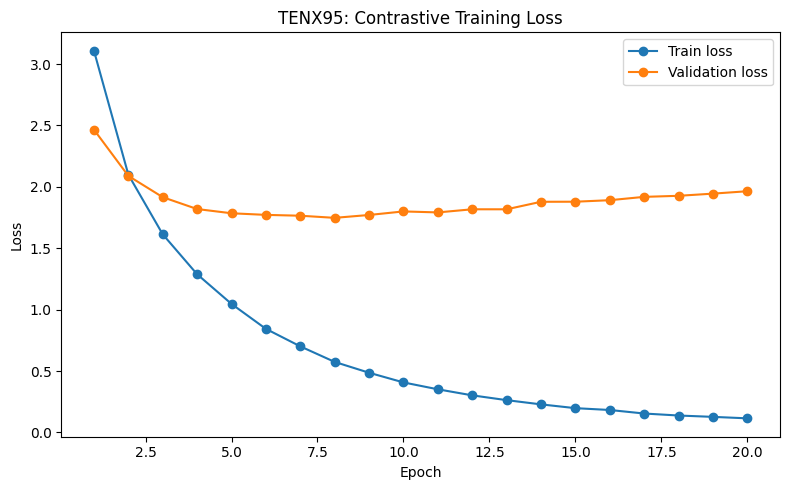

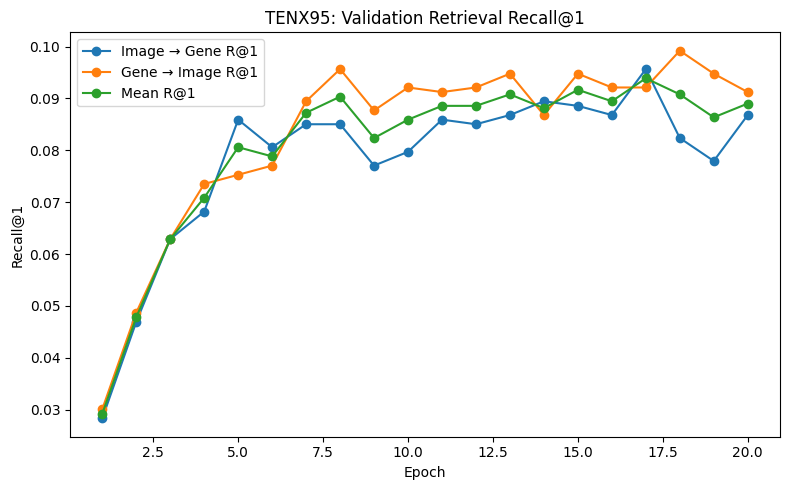

Saved loss figure: c:\Users\Hareen\Desktop\HistoGeneAlign\outputs\figures\TENX95_contrastive_training_loss.png
Saved recall figure: c:\Users\Hareen\Desktop\HistoGeneAlign\outputs\figures\TENX95_contrastive_validation_recall.png


In [26]:
# ============================================================
# Plot training curves
# ============================================================

LOSS_FIG_PATH = FIGURE_DIR / f"{SAMPLE_ID}_contrastive_training_loss.png"
RECALL_FIG_PATH = FIGURE_DIR / f"{SAMPLE_ID}_contrastive_validation_recall.png"

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"{SAMPLE_ID}: Contrastive Training Loss")
plt.legend()
plt.tight_layout()
plt.savefig(LOSS_FIG_PATH, dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["val_image_to_gene_R@1"], marker="o", label="Image → Gene R@1")
plt.plot(history_df["epoch"], history_df["val_gene_to_image_R@1"], marker="o", label="Gene → Image R@1")
plt.plot(history_df["epoch"], history_df["val_mean_R@1"], marker="o", label="Mean R@1")
plt.xlabel("Epoch")
plt.ylabel("Recall@1")
plt.title(f"{SAMPLE_ID}: Validation Retrieval Recall@1")
plt.legend()
plt.tight_layout()
plt.savefig(RECALL_FIG_PATH, dpi=300, bbox_inches="tight")
plt.show()

print("Saved loss figure:", LOSS_FIG_PATH)
print("Saved recall figure:", RECALL_FIG_PATH)

In [27]:
# ============================================================
# Loading the best validation model and evaluate test set
# ============================================================

assert best_state_dict is not None, "No best model state was saved."

model.load_state_dict(best_state_dict)
model = model.to(device)
model.eval()

test_loss = evaluate_loss(
    model=model,
    loader=test_loader,
    device=device,
    temperature=TEMPERATURE,
)

test_metrics = evaluate_retrieval(
    model=model,
    loader=test_loader,
    device=device,
)

final_test_report = {
    "sample_id": SAMPLE_ID,
    "image_encoder": "resnet50_imagenet1k_v2_frozen",
    "best_epoch": int(best_epoch),
    "test_loss": float(test_loss),
    **{k: float(v) for k, v in test_metrics.items()},
}

print("Final test report:")
print(json.dumps(final_test_report, indent=2))

with open(FINAL_TEST_METRICS_PATH, "w", encoding="utf-8") as f:
    json.dump(final_test_report, f, indent=2)

print("\nSaved final test metrics:", FINAL_TEST_METRICS_PATH)

Final test report:
{
  "sample_id": "TENX95",
  "image_encoder": "resnet50_imagenet1k_v2_frozen",
  "best_epoch": 17,
  "test_loss": 1.9760591201022664,
  "image_to_gene_R@1": 0.08584070950746536,
  "image_to_gene_R@5": 0.2929203510284424,
  "image_to_gene_R@10": 0.41504424810409546,
  "image_to_gene_MedianRank": 17.0,
  "image_to_gene_MeanRank": 61.44955825805664,
  "image_to_gene_MRR": 0.19008870422840118,
  "gene_to_image_R@1": 0.08584070950746536,
  "gene_to_image_R@5": 0.2743362784385681,
  "gene_to_image_R@10": 0.3840707838535309,
  "gene_to_image_MedianRank": 17.0,
  "gene_to_image_MeanRank": 60.03628158569336,
  "gene_to_image_MRR": 0.1859935224056244,
  "mean_R@1": 0.08584070950746536,
  "mean_R@5": 0.28362831473350525,
  "mean_R@10": 0.39955751597881317
}

Saved final test metrics: c:\Users\Hareen\Desktop\HistoGeneAlign\outputs\metrics\TENX95_contrastive_final_test_metrics.json


In [28]:
# ============================================================
# Saving the trained contrastive model checkpoint
# ============================================================

checkpoint = {
    "sample_id": SAMPLE_ID,
    "model_name": "HistoGeneAlign_ResNet50_Frozen_Contrastive_Baseline",
    "model_state_dict": model.state_dict(),
    "best_epoch": int(best_epoch),
    "best_val_mean_R@1": float(best_val_score),
    "hyperparameters": {
        "image_input_dim": IMAGE_INPUT_DIM,
        "gene_input_dim": GENE_INPUT_DIM,
        "hidden_dim": HIDDEN_DIM,
        "projection_dim": PROJECTION_DIM,
        "dropout": DROPOUT,
        "batch_size": BATCH_SIZE,
        "epochs": EPOCHS,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "temperature": TEMPERATURE,
        "seed": SEED,
    },
    "paths": {
        "qc_image_embedding_path": str(QC_IMAGE_EMBEDDING_PATH.relative_to(PROJECT_ROOT)),
        "qc_metadata_path": str(QC_METADATA_PATH.relative_to(PROJECT_ROOT)),
        "adata_path": str(ADATA_PATH.relative_to(PROJECT_ROOT)),
        "gene_feature_path": str(GENE_FEATURE_PATH.relative_to(PROJECT_ROOT)),
        "split_path": str(SPLIT_PATH.relative_to(PROJECT_ROOT)),
    },
    "gene_preprocessing": {
        "target_sum": TARGET_SUM,
        "transform": "library_size_normalization_to_10000_then_log1p_then_train_split_standard_scaling",
        "scaler_mean": gene_scaler.mean_.astype(np.float32),
        "scaler_scale": gene_scaler.scale_.astype(np.float32),
    },
    "test_metrics": final_test_report,
}

torch.save(checkpoint, CHECKPOINT_PATH)

print("Saved checkpoint:")
print(CHECKPOINT_PATH)

Saved checkpoint:
c:\Users\Hareen\Desktop\HistoGeneAlign\outputs\checkpoints\TENX95_resnet50_contrastive_baseline.pt


In [29]:
# ============================================================
# Save final contrastive latent embeddings for Notebook 06
#
# These are the aligned embeddings after projection:
#   image_latents_qc: N x 256
#   gene_latents_qc:  N x 256
# ============================================================

all_dataset = SpotContrastiveDataset(
    image_matrix=qc_image_embeddings,
    gene_matrix=gene_features,
    row_indices=np.arange(N),
)

all_loader = DataLoader(
    all_dataset,
    batch_size=256,
    shuffle=False,
    drop_last=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

all_rows, all_image_z, all_gene_z = encode_loader(
    model=model,
    loader=all_loader,
    device=device,
)

assert np.array_equal(all_rows, np.arange(N)), "All-loader row order is not sequential."

all_image_latents = all_image_z.numpy().astype(np.float32)
all_gene_latents = all_gene_z.numpy().astype(np.float32)

assert all_image_latents.shape == (N, PROJECTION_DIM)
assert all_gene_latents.shape == (N, PROJECTION_DIM)
assert np.isfinite(all_image_latents).all()
assert np.isfinite(all_gene_latents).all()

np.save(LATENT_IMAGE_PATH, all_image_latents)
np.save(LATENT_GENE_PATH, all_gene_latents)

split_labels = np.full(N, "none", dtype=object)
split_labels[train_idx] = "train"
split_labels[val_idx] = "val"
split_labels[test_idx] = "test"

latent_metadata = qc_metadata.copy()
latent_metadata["split"] = split_labels
latent_metadata["contrastive_embedding_row"] = np.arange(N, dtype=int)
latent_metadata["projection_dim"] = PROJECTION_DIM
latent_metadata["contrastive_model"] = "resnet50_frozen_gene_mlp_contrastive_baseline"

latent_metadata.to_csv(LATENT_METADATA_PATH, index=False)

print("Saved contrastive image latents:", LATENT_IMAGE_PATH)
print("Saved contrastive gene latents:", LATENT_GENE_PATH)
print("Saved latent metadata:", LATENT_METADATA_PATH)

print("\nLatent shapes:")
print("Image latents:", all_image_latents.shape)
print("Gene latents:", all_gene_latents.shape)

display(latent_metadata.head())

Saved contrastive image latents: c:\Users\Hareen\Desktop\HistoGeneAlign\data\embeddings\TENX95_resnet50_contrastive_image_latents_qc.npy
Saved contrastive gene latents: c:\Users\Hareen\Desktop\HistoGeneAlign\data\embeddings\TENX95_resnet50_contrastive_gene_latents_qc.npy
Saved latent metadata: c:\Users\Hareen\Desktop\HistoGeneAlign\data\embeddings\TENX95_contrastive_qc_metadata_with_splits.csv

Latent shapes:
Image latents: (7530, 256)
Gene latents: (7530, 256)


,embedding_row,sample_id,spot_id,patch_index,ann_data_row,x,y,patch_x,patch_y,library_size,detected_genes,valid_patch,valid_expression,encoder,embedding_dim,embedding_row_full,split,contrastive_embedding_row,projection_dim,contrastive_model
0,0,TENX95,006x022,0,640,10602.456959,3087.342422,10339,2824,1006,177,True,True,resnet50_imagenet_v2,2048,0,test,0,256,resnet50_frozen_gene_mlp_contrastive_baseline
1,1,TENX95,006x023,1,641,11073.045194,3087.342422,10810,2824,1219,239,True,True,resnet50_imagenet_v2,2048,1,train,1,256,resnet50_frozen_gene_mlp_contrastive_baseline
2,2,TENX95,006x024,2,642,11543.633429,3087.342422,11280,2824,5068,283,True,True,resnet50_imagenet_v2,2048,2,train,2,256,resnet50_frozen_gene_mlp_contrastive_baseline
3,3,TENX95,006x025,3,643,12014.221664,3087.342422,11751,2824,6534,299,True,True,resnet50_imagenet_v2,2048,3,train,3,256,resnet50_frozen_gene_mlp_contrastive_baseline
4,4,TENX95,006x026,4,644,12484.809900,3087.342422,12221,2824,3516,272,True,True,resnet50_imagenet_v2,2048,4,train,4,256,resnet50_frozen_gene_mlp_contrastive_baseline


In [30]:
# ============================================================
# Final checklist for this Notebook
# ============================================================

checklist = {
    "gene_feature_file_exists": GENE_FEATURE_PATH.exists(),
    "split_file_exists": SPLIT_PATH.exists(),
    "checkpoint_file_exists": CHECKPOINT_PATH.exists(),
    "training_history_file_exists": TRAINING_HISTORY_PATH.exists(),
    "test_metrics_file_exists": FINAL_TEST_METRICS_PATH.exists(),
    "image_latent_file_exists": LATENT_IMAGE_PATH.exists(),
    "gene_latent_file_exists": LATENT_GENE_PATH.exists(),
    "latent_metadata_file_exists": LATENT_METADATA_PATH.exists(),
    "image_latent_shape_correct": all_image_latents.shape == (N, PROJECTION_DIM),
    "gene_latent_shape_correct": all_gene_latents.shape == (N, PROJECTION_DIM),
    "metadata_row_count_correct": len(latent_metadata) == N,
    "split_labels_valid": set(latent_metadata["split"].unique()) == {"train", "val", "test"},
}

checklist_df = pd.DataFrame(
    [{"check": key, "passed": value} for key, value in checklist.items()]
)

display(checklist_df)

assert checklist_df["passed"].all(), "One or more Notebook 05 checks failed."

print("\nNotebook 05 completed successfully.")
print("\nUse these files for Notebook 06 retrieval evaluation:")
print(LATENT_IMAGE_PATH)
print(LATENT_GENE_PATH)
print(LATENT_METADATA_PATH)
print(FINAL_TEST_METRICS_PATH)

,check,passed
0,gene_feature_file_exists,True
1,split_file_exists,True
2,checkpoint_file_exists,True
3,training_history_file_exists,True
4,test_metrics_file_exists,True
5,image_latent_file_exists,True
6,gene_latent_file_exists,True
7,latent_metadata_file_exists,True
8,image_latent_shape_correct,True
9,gene_latent_shape_correct,True



Notebook 05 completed successfully.

Use these files for Notebook 06 retrieval evaluation:
c:\Users\Hareen\Desktop\HistoGeneAlign\data\embeddings\TENX95_resnet50_contrastive_image_latents_qc.npy
c:\Users\Hareen\Desktop\HistoGeneAlign\data\embeddings\TENX95_resnet50_contrastive_gene_latents_qc.npy
c:\Users\Hareen\Desktop\HistoGeneAlign\data\embeddings\TENX95_contrastive_qc_metadata_with_splits.csv
c:\Users\Hareen\Desktop\HistoGeneAlign\outputs\metrics\TENX95_contrastive_final_test_metrics.json
